# Air Quality Index (AQI) Prediction - Exploratory Data Analysis

This notebook performs the Exploratory Data Analysis (EDA) for the **Air Quality Prediction System**.
We investigate the relationships between environmental pollutants ($PM_{2.5}, PM_{10}, NO_2, SO_2, CO, O_3$), weather conditions (Temperature, Humidity, Wind Speed), and the calculated CPCB Air Quality Index (AQI).

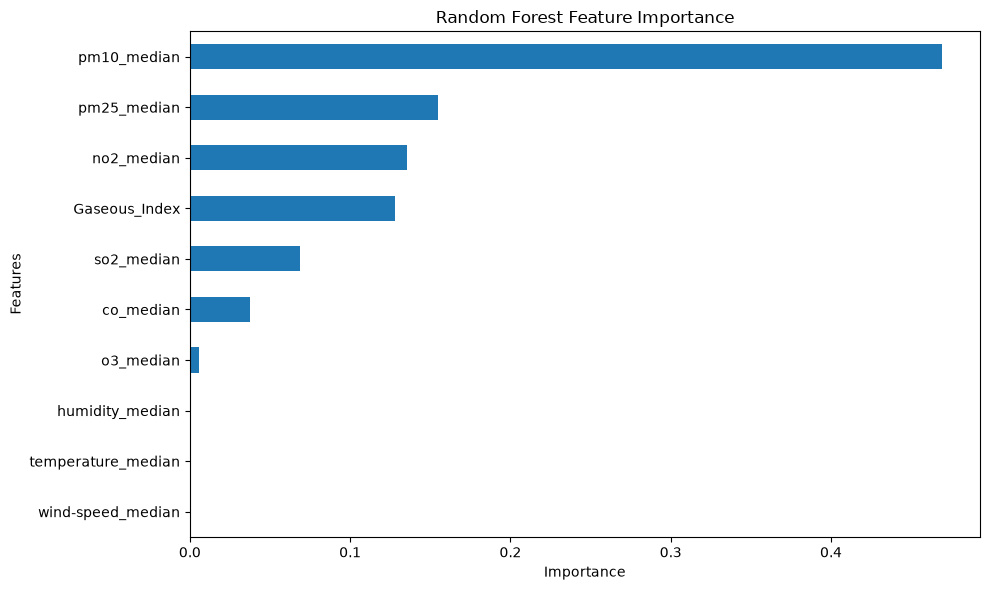

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_imp = pd.read_csv('../reports/feature_importances.csv')
importance = pd.Series(df_imp['Importance'].values, index=df_imp['Feature'])

plt.figure(figsize=(10, 6))

importance.sort_values().tail(10).plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Cleaned Dataset

In [ ]:
# Load the cleaned dataset
data_path = "../data/processed/cleaned_air_quality.csv"
df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape}")
df.head()

## 2. Target Variable (AQI) Distribution
Let's see how the target variable, AQI, is distributed. This determines if we have balanced representation of air quality severity levels.

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['AQI'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Air Quality Index (AQI)')
plt.xlabel('AQI Value')
plt.ylabel('Count')
plt.show()

## 3. Pollutant Distributions
Let's plot the distributions of key pollutants. This reveals skewness and typical ranges of concentration.

In [ ]:
key_pollutants = {
    'pm25_median': 'PM2.5',
    'pm10_median': 'PM10',
    'no2_median': 'NO2',
    'so2_median': 'SO2',
    'co_median': 'CO',
    'o3_median': 'O3'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, (col, name) in enumerate(key_pollutants.items()):
    sns.histplot(df[col].dropna(), kde=True, bins=40, ax=axes[i], color='forestgreen')
    axes[i].set_title(f'Distribution of {name}')
    axes[i].set_xlabel('Concentration')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Correlation Analysis
Analyzing correlations shows the linear relationships between predictors and the target AQI. It also highlights multicollinearity (high correlation between features).

In [ ]:
weather_params = {
    'temperature_median': 'Temperature',
    'humidity_median': 'Humidity',
    'wind-speed_median': 'Wind Speed'
}

cols_for_corr = list(key_pollutants.keys()) + list(weather_params.keys()) + ['AQI']
rename_dict = {**key_pollutants, **weather_params, 'AQI': 'AQI'}
corr_matrix = df[cols_for_corr].rename(columns=rename_dict).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Pollutants, Weather & AQI')
plt.show()

## 5. Pollutants vs AQI Relationships
Let's see if the pollutants display a linear or non-linear relationship with AQI.

In [ ]:
# Sample data points to keep scatter plots readable
sample_df = df.sample(n=min(2000, len(df)), random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, (col, name) in enumerate(key_pollutants.items()):
    sns.scatterplot(x=col, y='AQI', data=sample_df, ax=axes[i], alpha=0.5, color='coral')
    sns.regplot(x=col, y='AQI', data=sample_df, ax=axes[i], scatter=False, color='red')
    axes[i].set_title(f'{name} vs AQI')
    axes[i].set_xlabel(f'{name} Concentration')
    axes[i].set_ylabel('AQI')

plt.tight_layout()
plt.show()

## 6. Weather Conditions vs AQI
Let's examine how meteorological parameters influence AQI.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, name) in enumerate(weather_params.items()):
    sns.scatterplot(x=col, y='AQI', data=sample_df, ax=axes[i], alpha=0.5, color='purple')
    sns.regplot(x=col, y='AQI', data=sample_df, ax=axes[i], scatter=False, color='black')
    axes[i].set_title(f'{name} vs AQI')
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('AQI')

plt.tight_layout()
plt.show()

## 7. Time-based Trends
Let's plot monthly trends to see if there is seasonality in the air quality.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
monthly_aqi = df.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi['Month'] = monthly_aqi['Month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='AQI', data=monthly_aqi, marker='o', color='darkorange', linewidth=2.5)
plt.title('Monthly Average AQI Trend')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.show()